In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid  tableau-colorblind10

In [2]:
len_cf = 101  # add 1 as CFs value starting from year_0
MYs = [2020, 2030, 2040, 2050] #, 2060, 2070]
ssps = ["119", "245", "585"]   #"126"
sp_col, my_col = [], []

#### under fixed_AGWPCO2 approach, a future CO2 itself no longer has GWP=1 

In [3]:
ghggass = ['CO2']

from collections import defaultdict
#  3-layer nested dict
cf_col_gas_allgas = defaultdict(lambda: defaultdict(dict))

for ghggas in ghggass: 
    cf_col_gas = []
    for sp in ssps:
        for MY in MYs:
            #print(f"read point GWP value for {ghggas} SSP {sp}, model year {MY}")
            filename = "agwp_dcf_gwp100_tstep1" + ghggas + "_ssp" + sp + "_fair_start2000MY" + str(MY) + ".xlsx"
            cf_file = os.path.join("../FaIR_dpCFs/output/metrics/", filename)

            cf_agwp_df = pd.read_excel(cf_file, sheet_name = "agwp_pointvalue" + ghggas+ "_" + str(MY) ) 
            cf_agwp_pointvalue = cf_agwp_df[ghggas].values
            cf_col_gas.append(cf_agwp_pointvalue)
    
            cf_col_gas_allgas[ghggas][f'ssp{sp}'][str(MY)] = cf_agwp_pointvalue

In [4]:
cf_col_gas_allgas['CO2']['ssp119']['2030']

array([0.00000000e+00, 1.88991172e-15, 3.66401365e-15, 5.34343629e-15,
       6.94500147e-15, 8.48211368e-15, 9.96546670e-15, 1.14036037e-14,
       1.28033616e-14, 1.41702226e-14, 1.55085938e-14, 1.68220283e-14,
       1.81134006e-14, 1.93850458e-14, 2.06388699e-14, 2.18764373e-14,
       2.30990402e-14, 2.43077537e-14, 2.55034792e-14, 2.66869794e-14,
       2.78589056e-14, 2.90198196e-14, 3.01702112e-14, 3.13105114e-14,
       3.24411042e-14, 3.35623346e-14, 3.46745160e-14, 3.57779354e-14,
       3.68728580e-14, 3.79595308e-14, 3.90381851e-14, 4.01090391e-14,
       4.11722996e-14, 4.22281633e-14, 4.32768185e-14, 4.43184451e-14,
       4.53532167e-14, 4.63812999e-14, 4.74028559e-14, 4.84180403e-14,
       4.94270038e-14, 5.04298923e-14, 5.14268475e-14, 5.24180065e-14,
       5.34035028e-14, 5.43834659e-14, 5.53580218e-14, 5.63272927e-14,
       5.72913977e-14, 5.82504526e-14, 5.92045699e-14, 6.01538591e-14,
       6.10984270e-14, 6.20383772e-14, 6.29738107e-14, 6.39048257e-14,
      

In [5]:
agwp_co2 =  pd.read_excel('AGWP_CO2_fixed.xlsx' )
agwp_co2_TH101 = agwp_co2.iloc[:101]
#agwp_co2_TH101
agwp_co2_vals = agwp_co2_TH101['AGWP_CO2_fixed'].values[1:]  # shape (100,)
agwp_co2_vals.shape

(100,)

### AGWP[future CO2] / AGWP[2019 CO2] 

In [6]:
# Output dictionary to store GWP values
gwp_results = {}

for ghg in cf_col_gas_allgas:
    gwp_results[ghg] = {}
    for ssp in cf_col_gas_allgas[ghg]:
        gwp_results[ghg][ssp] = {}
        
        for MY in cf_col_gas_allgas[ghg][ssp]:
            arr = cf_col_gas_allgas[ghg][ssp][MY]

            arr_trimmed = arr[1:101]  # drops 0th element, keeps next 100

            # get GWP values (elementwise divide by CO2 AGWP)
            gwp_array = arr_trimmed / agwp_co2_vals

            # Store result
            gwp_results[ghg][ssp][MY] = gwp_array

In [7]:
gwp_results['CO2']['ssp119']['2030']

array([1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474948,
       1.14474948, 1.14474948, 1.14474948, 1.14474948, 1.14474

In [8]:
gwp_results['CO2']['ssp119']['2050']

array([1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857

In [9]:
gwp_results['CO2']['ssp585']['2050']

array([0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357576,
       0.90357576, 0.90357576, 0.90357576, 0.90357576, 0.90357

In [10]:
gwp_results['CO2']['ssp119']['2050']

array([1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857906,
       1.13857906, 1.13857906, 1.13857906, 1.13857906, 1.13857

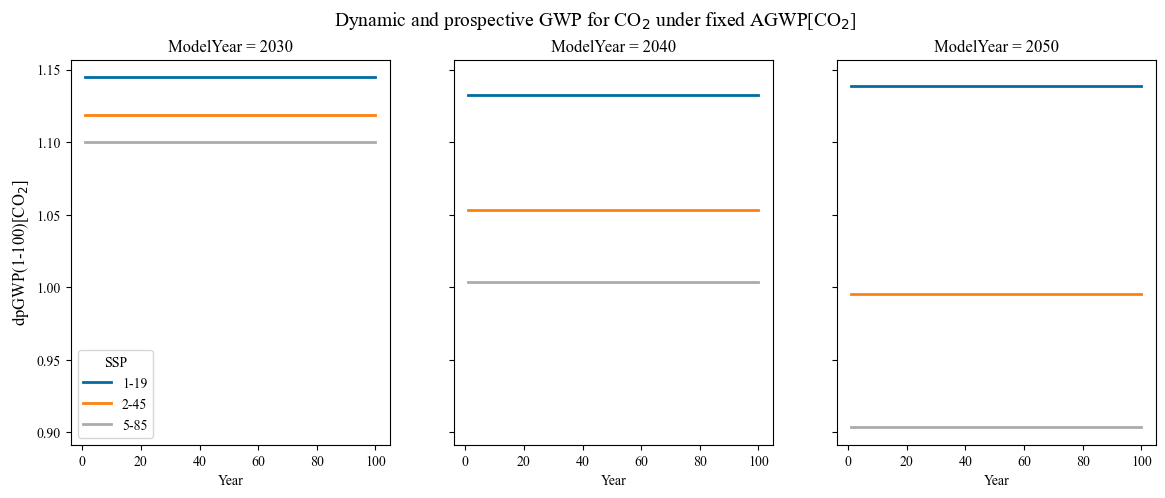

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CO2'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CO$_2$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CO$_2$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()


### we'll combine the new GWP[CO2] together with CH4/N2O in a new df and .nc 